# Phase 5 — Power BI Dashboard Preparation

## 1. Introduction

Phases 1–4 built **`fact_sales`**, advanced analytics, forecasting, and anomaly recommendations.

**Phase 5** prepares **clean, export-ready datasets** for a Power BI dashboard with four pages:

1. **Executive Overview** — KPIs and growth  
2. **Sales Trends** — daily/monthly trends and forecast vs actual  
3. **Product Insights** — categories and underperformers  
4. **Regional Analysis** — revenue and growth by region  

All tables are exported to the **`exports/`** folder for import into Power BI.

> **Prerequisite:** Phase 1 completed; optional Phase 3 for forecast files in `outputs/`.


## 2. Library Imports & PostgreSQL Connection

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sqlalchemy import create_engine, text
from sqlalchemy.engine import Engine

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (10, 5)

PG_USER = os.environ.get("PGUSER", "postgres")
PG_PASSWORD = os.environ.get("PGPASSWORD", "kanna")
PG_HOST = os.environ.get("PGHOST", "localhost")
PG_PORT = os.environ.get("PGPORT", "5432")
PG_DATABASE = os.environ.get("PGDATABASE", "sales_db")

CONNECTION_STRING = os.environ.get(
    "DATABASE_URL",
    f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DATABASE}",
)
engine: Engine = create_engine(CONNECTION_STRING)

WORKSPACE = Path.cwd()
EXPORT_DIR = WORKSPACE / "exports"
OUTPUT_DIR = WORKSPACE / "outputs"
EXPORT_DIR.mkdir(exist_ok=True)

def run_sql(sql: str) -> pd.DataFrame:
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

def export_csv(df: pd.DataFrame, name: str) -> Path:
    path = EXPORT_DIR / name
    df.to_csv(path, index=False)
    print(f"Exported {path} ({len(df):,} rows)")
    return path

print("Connection ready. Export folder:", EXPORT_DIR)


Connection ready. Export folder: d:\NCPL\Bootcamp\Projects\Project 3\data\exports


## 3. Load Data from PostgreSQL

Load `fact_sales` and build a **date dimension** for Power BI relationships.


In [2]:
fact = run_sql("SELECT * FROM fact_sales ORDER BY order_date")
fact["order_date"] = pd.to_datetime(fact["order_date"])

print(f"fact_sales: {len(fact):,} rows × {fact.shape[1]} columns")
display(fact.head())

# Date dimension (for slicers & hierarchies)
dmin, dmax = fact["order_date"].min(), fact["order_date"].max()
date_dim = pd.DataFrame({"date": pd.date_range(dmin, dmax, freq="D")})
date_dim["year"] = date_dim["date"].dt.year
date_dim["quarter"] = "Q" + date_dim["date"].dt.quarter.astype(str)
date_dim["month_num"] = date_dim["date"].dt.month
date_dim["month_name"] = date_dim["date"].dt.strftime("%B")
date_dim["year_month"] = date_dim["date"].dt.to_period("M").astype(str)
date_dim["day"] = date_dim["date"].dt.day
date_dim["day_of_week"] = date_dim["date"].dt.day_name()
date_dim["is_weekend"] = date_dim["date"].dt.dayofweek >= 5

display(date_dim.head())


fact_sales: 112,650 rows × 17 columns


,order_id,order_item_id,order_date,customer_location,product_category,price,quantity,total_revenue,payment_type,delivery_time,freight_value,seller_id,seller_region,review_score,payment_installments,customer_lat,customer_lng
0,2e7a8482f6fb09756ca50c10d7bfc047,1,2016-09-04,boa vista,furniture_decor,39.99,1,39.99,credit_card,NaN,31.67,1554a68530182680ad5c8b042c3ab563,MG,1.0,1.0,2.813746,-60.701007
1,2e7a8482f6fb09756ca50c10d7bfc047,2,2016-09-04,boa vista,furniture_decor,32.90,1,32.90,credit_card,NaN,31.67,1554a68530182680ad5c8b042c3ab563,MG,1.0,1.0,2.813746,-60.701007
2,e5fa5a7210941f7d56d0208e4e071d35,1,2016-09-05,passo fundo,telephony,59.50,1,59.50,credit_card,NaN,15.56,a425f92c199eb576938df686728acd20,PR,1.0,3.0,-28.264640,-52.425421
3,bfbd0f9bdef84302105ad712db648a6c,2,2016-09-15,sao joaquim da barra,health_beauty,44.99,1,44.99,Unknown,55.0,2.83,ecccfa2bb93b34a3bf033cc5d1dcdc69,PR,1.0,NaN,-20.585751,-47.863693
4,bfbd0f9bdef84302105ad712db648a6c,3,2016-09-15,sao joaquim da barra,health_beauty,44.99,1,44.99,Unknown,55.0,2.83,ecccfa2bb93b34a3bf033cc5d1dcdc69,PR,1.0,NaN,-20.585751,-47.863693


,date,year,quarter,month_num,month_name,year_month,day,day_of_week,is_weekend
0,2016-09-04,2016,Q3,9,September,2016-09,4,Sunday,True
1,2016-09-05,2016,Q3,9,September,2016-09,5,Monday,False
2,2016-09-06,2016,Q3,9,September,2016-09,6,Tuesday,False
3,2016-09-07,2016,Q3,9,September,2016-09,7,Wednesday,False
4,2016-09-08,2016,Q3,9,September,2016-09,8,Thursday,False


---

# Section 1 — Executive Overview Datasets

## 4. Compute Key Metrics


In [3]:
calc_date = pd.Timestamp.today().normalize()

total_revenue = fact["total_revenue"].sum()
total_orders = fact["order_id"].nunique()
total_line_items = len(fact)
aov = total_revenue / total_orders if total_orders else np.nan

monthly = (
    fact.assign(year_month=fact["order_date"].dt.to_period("M"))
    .groupby("year_month")["total_revenue"]
    .sum()
    .sort_index()
)
mom_growth = np.nan
if len(monthly) >= 2:
    mom_growth = (monthly.iloc[-1] / monthly.iloc[-2] - 1) * 100

yearly = fact.groupby(fact["order_date"].dt.year)["total_revenue"].sum()
yoy_growth = np.nan
if len(yearly) >= 2:
    yoy_growth = (yearly.iloc[-1] / yearly.iloc[-2] - 1) * 100

metrics = {
    "total_revenue": total_revenue,
    "total_orders": total_orders,
    "total_line_items": total_line_items,
    "average_order_value": aov,
    "mom_growth_pct": mom_growth,
    "yoy_growth_pct": yoy_growth,
}
for k, v in metrics.items():
    print(f"{k}: {v:,.2f}" if isinstance(v, float) else f"{k}: {v:,}")


total_revenue: 13,591,643.70
total_orders: 98,666
total_line_items: 112,650
average_order_value: 137.75
mom_growth_pct: -99.98
yoy_growth_pct: 19.99


## 5. Summary Table for Power BI (long / unpivot-friendly)


In [4]:
executive_overview = pd.DataFrame([
    {"metric_name": "Total Revenue", "metric_value": metrics["total_revenue"], "calculation_date": calc_date},
    {"metric_name": "Total Orders", "metric_value": metrics["total_orders"], "calculation_date": calc_date},
    {"metric_name": "Total Line Items", "metric_value": metrics["total_line_items"], "calculation_date": calc_date},
    {"metric_name": "Average Order Value", "metric_value": metrics["average_order_value"], "calculation_date": calc_date},
    {"metric_name": "MoM Growth %", "metric_value": metrics["mom_growth_pct"], "calculation_date": calc_date},
    {"metric_name": "YoY Growth %", "metric_value": metrics["yoy_growth_pct"], "calculation_date": calc_date},
])
display(executive_overview)


,metric_name,metric_value,calculation_date
0,Total Revenue,1.359164e+07,2026-05-18
1,Total Orders,9.866600e+04,2026-05-18
2,Total Line Items,1.126500e+05,2026-05-18
3,Average Order Value,1.377541e+02,2026-05-18
4,MoM Growth %,-9.998303e+01,2026-05-18
5,YoY Growth %,1.998509e+01,2026-05-18


## 6. Export Executive Overview


In [5]:
export_csv(executive_overview, "executive_overview.csv")


Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\executive_overview.csv (6 rows)


WindowsPath('d:/NCPL/Bootcamp/Projects/Project 3/data/exports/executive_overview.csv')

---

# Section 2 — Sales Trends Datasets

## 7. Daily Sales Trend


In [6]:
daily_sales = (
    fact.groupby(fact["order_date"].dt.date)["total_revenue"]
    .sum()
    .reset_index()
    .rename(columns={"order_date": "date", "total_revenue": "revenue"})
)
daily_sales["date"] = pd.to_datetime(daily_sales["date"])
display(daily_sales.head())


,date,revenue
0,2016-09-04,72.89
1,2016-09-05,59.50
2,2016-09-15,134.97
3,2016-10-02,100.00
4,2016-10-03,463.48


## 8. Monthly Sales Trend


In [7]:
monthly_sales = (
    fact.assign(month_start=fact["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month_start")["total_revenue"]
    .sum()
    .reset_index()
    .rename(columns={"month_start": "month", "total_revenue": "revenue"})
)
monthly_sales["year"] = monthly_sales["month"].dt.year
monthly_sales["month_num"] = monthly_sales["month"].dt.month
display(monthly_sales.head())


,month,revenue,year,month_num
0,2016-09-01,267.36,2016,9
1,2016-10-01,49507.66,2016,10
2,2016-12-01,10.90,2016,12
3,2017-01-01,120312.87,2017,1
4,2017-02-01,247303.02,2017,2


## 9. Forecast vs Actual

Merge historical actuals with Phase 3 test predictions (`outputs/phase3_test_predictions.csv`).


In [8]:
phase3_path = OUTPUT_DIR / "phase3_test_predictions.csv"
forecast_vs_actual = daily_sales.rename(columns={"revenue": "actual_revenue"}).copy()

if phase3_path.exists():
    fc = pd.read_csv(phase3_path)
    if "date" not in fc.columns:
        fc = fc.rename(columns={fc.columns[0]: "date"})
    fc["date"] = pd.to_datetime(fc["date"])
    fc = fc.rename(columns={
        "actual": "actual_revenue_fc",
        "arima": "arima_forecast",
        "prophet": "prophet_forecast",
        "lstm": "lstm_forecast",
    })
    forecast_vs_actual = forecast_vs_actual.merge(fc, on="date", how="left")
    for c in ["arima_forecast", "prophet_forecast", "lstm_forecast"]:
        if c not in forecast_vs_actual.columns:
            forecast_vs_actual[c] = np.nan
    print("Merged Phase 3 forecasts on test period.")
else:
    forecast_vs_actual["arima_forecast"] = np.nan
    forecast_vs_actual["prophet_forecast"] = np.nan
    forecast_vs_actual["lstm_forecast"] = np.nan
    print("Phase 3 file not found — forecast columns left null. Run Phase 3 first.")

display(forecast_vs_actual.dropna(subset=["arima_forecast"], how="all").head(10))


Merged Phase 3 forecasts on test period.


,date,actual_revenue,actual_revenue_fc,arima_forecast,prophet_forecast,lstm_forecast
530,2018-06-06,26134.40,26134.40,27971.719259,30173.796602,NaN
531,2018-06-07,37020.40,37020.40,26982.782407,29383.343991,NaN
532,2018-06-08,26870.41,26870.41,26982.782407,29588.384338,NaN
533,2018-06-09,29325.08,29325.08,26982.782407,25359.579271,NaN
534,2018-06-10,25501.97,25501.97,26982.782407,26088.004096,NaN
535,2018-06-11,49669.70,49669.70,26982.782407,31984.840289,NaN
536,2018-06-12,40369.00,40369.00,26982.782407,31725.027085,NaN
537,2018-06-13,34616.96,34616.96,26982.782407,31431.665927,NaN
538,2018-06-14,27504.60,27504.60,26982.782407,30686.250050,NaN
539,2018-06-15,26617.56,26617.56,26982.782407,30897.593313,NaN


## 10. Export Sales Trend Datasets


In [9]:
export_csv(daily_sales, "daily_sales.csv")
export_csv(monthly_sales, "monthly_sales.csv")
export_csv(forecast_vs_actual, "forecast_vs_actual.csv")


Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\daily_sales.csv (616 rows)
Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\monthly_sales.csv (24 rows)
Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\forecast_vs_actual.csv (616 rows)


WindowsPath('d:/NCPL/Bootcamp/Projects/Project 3/data/exports/forecast_vs_actual.csv')

---

# Section 3 — Product Insights Datasets

## 11. Top Categories


In [10]:
top_categories = (
    fact.groupby("product_category", as_index=False)
    .agg(revenue=("total_revenue", "sum"), quantity=("quantity", "sum"), orders=("order_id", "nunique"))
    .sort_values("revenue", ascending=False)
)
top_categories["rank"] = np.arange(1, len(top_categories) + 1)
display(top_categories.head(15))


,product_category,revenue,quantity,orders,rank
44,health_beauty,1258681.34,9670,8836,1
73,watches_gifts,1205005.68,5991,5624,2
8,bed_bath_table,1036988.68,11115,9417,3
68,sports_leisure,988048.97,8641,7720,4
16,computers_accessories,911954.32,7827,6689,5
40,furniture_decor,729762.49,8334,6449,6
21,cool_stuff,635290.85,3796,3632,7
50,housewares,632248.66,6964,5884,8
6,auto,592720.11,4235,3897,9
43,garden_tools,485256.46,4347,3518,10


## 12. Low-Performing Products

Product grain from `staging_products` joined to `fact_sales` via order keys.


In [11]:
low_sql = '''
SELECT
  p.product_id,
  COALESCE(NULLIF(TRIM(p.product_name), ''), p.product_category) AS product_name,
  p.product_category,
  SUM(f.total_revenue) AS revenue,
  SUM(f.quantity) AS quantity
FROM fact_sales f
JOIN staging_orders o ON f.order_id = o.order_id AND f.order_item_id = o.order_item_id
JOIN staging_products p ON o.product_id = p.product_id
GROUP BY 1, 2, 3
ORDER BY revenue ASC
LIMIT 10;
'''
try:
    low_performing_products = run_sql(low_sql)
except Exception:
    low_performing_products = (
        top_categories.sort_values("revenue")
        .head(10)
        .rename(columns={"product_category": "product_name"})
        .assign(product_id=range(1, 11), product_category=lambda x: x["product_name"])
    )
    print("Used category-level fallback (staging join unavailable).")

display(low_performing_products)


,product_id,product_name,product_category,revenue,quantity
0,46fce52cef5caa7cc225a5531c946c8b,health_beauty,health_beauty,2.20,1
1,310dc32058903b6416c71faff132df9e,stationery,stationery,2.29,1
2,8a3254bee785a526d548a81a9bc3c9be,construction_tools_construction,construction_tools_construction,2.55,3
3,680cc8535be7cc69544238c1d6a83fe8,pet_shop,pet_shop,2.90,1
4,2e8316b31db34314f393806fd7b6e185,stationery,stationery,2.99,1
5,5304ff3fa35856a156e1170a6022d34d,art,art,3.50,1
6,0eeeb45e2f5911fd44282e5bb0c624ff,music,music,3.85,1
7,836c4b48c2b383bb38bb5788f828c596,fashion_underwear_beach,fashion_underwear_beach,3.90,1
8,c2fb26742f8484dbfe9a8d70bdc54025,computers_accessories,computers_accessories,3.90,1
9,dc9f66a56b89e4278d921898a861a29a,Unknown,Unknown,3.90,1


## 13. Export Product Datasets


In [12]:
export_csv(top_categories, "top_categories.csv")
export_csv(low_performing_products, "low_performing_products.csv")


Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\top_categories.csv (74 rows)
Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\low_performing_products.csv (10 rows)


WindowsPath('d:/NCPL/Bootcamp/Projects/Project 3/data/exports/low_performing_products.csv')

---

# Section 4 — Regional Analysis Datasets

## 14. Sales by Region

Region = customer state from staging; city = `customer_location` in fact.


In [13]:
region_sql = '''
SELECT
  COALESCE(NULLIF(TRIM(c.region), ''), NULLIF(TRIM(f.seller_region), ''), 'Unknown') AS region,
  f.customer_location AS city,
  SUM(f.total_revenue) AS revenue,
  COUNT(DISTINCT f.order_id) AS orders,
  SUM(f.quantity) AS quantity
FROM fact_sales f
LEFT JOIN staging_orders o ON f.order_id = o.order_id AND f.order_item_id = o.order_item_id
LEFT JOIN staging_customers c ON o.customer_id = c.customer_id
GROUP BY 1, 2
ORDER BY revenue DESC;
'''
try:
    sales_by_region_detail = run_sql(region_sql)
    sales_by_region = (
        sales_by_region_detail.groupby("region", as_index=False)
        .agg(revenue=("revenue", "sum"), orders=("orders", "sum"), quantity=("quantity", "sum"))
        .sort_values("revenue", ascending=False)
    )
except Exception:
    sales_by_region = (
        fact.groupby("customer_location", as_index=False)["total_revenue"]
        .sum()
        .rename(columns={"customer_location": "region", "total_revenue": "revenue"})
        .sort_values("revenue", ascending=False)
    )
    sales_by_region_detail = sales_by_region.assign(city=sales_by_region["region"])

display(sales_by_region.head(10))


,region,revenue,orders,quantity
25,SP,5202955.05,41375,47449
18,RJ,1824092.67,12762,14579
10,MG,1585308.03,11544,13129
22,RS,750304.02,5432,6235
17,PR,683083.76,4998,5740
23,SC,520553.34,3612,4176
4,BA,511349.99,3358,3799
6,DF,302603.94,2125,2406
8,GO,294591.95,2007,2333
7,ES,275037.31,2025,2256


## 15. High-Growth Regions

Compare latest full month vs prior month by region.


In [14]:
fact_r = fact.copy()
fact_r["year_month"] = fact_r["order_date"].dt.to_period("M")
months = sorted(fact_r["year_month"].unique())
if len(months) >= 2:
    cur, prev = months[-1], months[-2]
    reg_sql = '''
    SELECT
      COALESCE(NULLIF(TRIM(c.region), ''), f.seller_region, 'Unknown') AS region,
      TO_CHAR(f.order_date, 'YYYY-MM') AS year_month,
      SUM(f.total_revenue) AS revenue
    FROM fact_sales f
    LEFT JOIN staging_orders o ON f.order_id = o.order_id AND f.order_item_id = o.order_item_id
    LEFT JOIN staging_customers c ON o.customer_id = c.customer_id
    GROUP BY 1, 2;
    '''
    try:
        reg_m = run_sql(reg_sql)
        reg_m["year_month"] = pd.PeriodIndex(reg_m["year_month"], freq="M")
        cur_m = str(months[-1])
        prev_m = str(months[-2])
        c_slice = reg_m[reg_m["year_month"] == months[-1]].set_index("region")["revenue"]
        p_slice = reg_m[reg_m["year_month"] == months[-2]].set_index("region")["revenue"]
        growth = ((c_slice / p_slice.replace(0, np.nan)) - 1) * 100
        high_growth_regions = (
            growth.dropna()
            .sort_values(ascending=False)
            .head(5)
            .reset_index()
            .rename(columns={"revenue": "growth_pct"})
        )
        high_growth_regions["current_month"] = cur_m
        high_growth_regions["prior_month"] = prev_m
    except Exception:
        high_growth_regions = sales_by_region.head(5).assign(growth_pct=np.nan)
else:
    high_growth_regions = sales_by_region.head(5).assign(growth_pct=np.nan)

display(high_growth_regions)


,region,growth_pct,current_month,prior_month
0,SP,-99.96344,2018-09,2018-08


## 16. Export Regional Datasets


In [15]:
export_csv(sales_by_region, "sales_by_region.csv")
export_csv(high_growth_regions, "high_growth_regions.csv")
# Optional detail table for city drill-down in Power BI
if "sales_by_region_detail" in dir():
    export_csv(sales_by_region_detail, "sales_by_region_city.csv")


Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\sales_by_region.csv (27 rows)
Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\high_growth_regions.csv (1 rows)
Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\sales_by_region_city.csv (4,300 rows)


---

# Section 5 — Power BI Features Preparation

## 17. Slicer Tables


In [16]:
region_slicer = (
    sales_by_region[["region"]].drop_duplicates().sort_values("region").reset_index(drop=True)
)
category_slicer = (
    fact[["product_category"]].drop_duplicates().sort_values("product_category").reset_index(drop=True)
    .rename(columns={"product_category": "category"})
)
date_slicer = date_dim[["date", "year", "month_name", "year_month"]].copy()

display(region_slicer.head())
display(category_slicer.head())
display(date_slicer.head())


,region
0,AC
1,AL
2,AM
3,AP
4,BA


,category
0,Unknown
1,agro_industry_and_commerce
2,air_conditioning
3,art
4,arts_and_craftmanship


,date,year,month_name,year_month
0,2016-09-04,2016,September,2016-09
1,2016-09-05,2016,September,2016-09
2,2016-09-06,2016,September,2016-09
3,2016-09-07,2016,September,2016-09
4,2016-09-08,2016,September,2016-09


## 18. Drill-Down Hierarchies

Long-format hierarchy table for Power BI modeling (Date, Product, Region).


In [17]:
# Date paths
date_hier = date_dim[["date", "year", "quarter", "year_month", "month_name", "day"]].copy()
date_hier["hierarchy_type"] = "Date"
date_hier = date_hier.rename(columns={
    "year": "level_1",
    "quarter": "level_2",
    "year_month": "level_3",
    "date": "level_4",
})

# Product paths (category → product from staging)
try:
    prod_hier = run_sql('''
        SELECT DISTINCT product_category AS level_1,
               COALESCE(NULLIF(TRIM(product_name), ''), product_category) AS level_2
        FROM staging_products
        WHERE product_category IS NOT NULL
    ''')
    prod_hier["hierarchy_type"] = "Product"
    prod_hier["level_3"] = ""
    prod_hier["level_4"] = ""
except Exception:
    prod_hier = top_categories[["product_category"]].rename(columns={"product_category": "level_1"})
    prod_hier["level_2"] = prod_hier["level_1"]
    prod_hier["hierarchy_type"] = "Product"
    prod_hier["level_3"] = ""
    prod_hier["level_4"] = ""

# Region paths
if "sales_by_region_detail" in dir() and "city" in sales_by_region_detail.columns:
    reg_hier = sales_by_region_detail[["region", "city"]].drop_duplicates()
    reg_hier = reg_hier.rename(columns={"region": "level_1", "city": "level_2"})
else:
    reg_hier = sales_by_region[["region"]].rename(columns={"region": "level_1"})
    reg_hier["level_2"] = reg_hier["level_1"]
reg_hier["hierarchy_type"] = "Region"
reg_hier["level_3"] = ""
reg_hier["level_4"] = ""

hierarchies = pd.concat([
    date_hier[["hierarchy_type", "level_1", "level_2", "level_3", "level_4"]],
    prod_hier[["hierarchy_type", "level_1", "level_2", "level_3", "level_4"]],
    reg_hier[["hierarchy_type", "level_1", "level_2", "level_3", "level_4"]],
], ignore_index=True)

display(hierarchies.head(10))


,hierarchy_type,level_1,level_2,level_3,level_4
0,Date,2016,Q3,2016-09,2016-09-04 00:00:00
1,Date,2016,Q3,2016-09,2016-09-05 00:00:00
2,Date,2016,Q3,2016-09,2016-09-06 00:00:00
3,Date,2016,Q3,2016-09,2016-09-07 00:00:00
4,Date,2016,Q3,2016-09,2016-09-08 00:00:00
5,Date,2016,Q3,2016-09,2016-09-09 00:00:00
6,Date,2016,Q3,2016-09,2016-09-10 00:00:00
7,Date,2016,Q3,2016-09,2016-09-11 00:00:00
8,Date,2016,Q3,2016-09,2016-09-12 00:00:00
9,Date,2016,Q3,2016-09,2016-09-13 00:00:00


## 19. Export Slicer & Hierarchy Tables


In [18]:
export_csv(region_slicer, "region_slicer.csv")
export_csv(category_slicer, "category_slicer.csv")
export_csv(date_slicer, "date_slicer.csv")
export_csv(hierarchies, "hierarchies.csv")
export_csv(date_dim, "date_dimension.csv")

# Master manifest for Power BI import
manifest = pd.DataFrame({
    "file": sorted([p.name for p in EXPORT_DIR.glob("*.csv")]),
    "folder": str(EXPORT_DIR),
})
display(manifest)


Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\region_slicer.csv (27 rows)
Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\category_slicer.csv (74 rows)
Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\date_slicer.csv (730 rows)
Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\hierarchies.csv (5,104 rows)
Exported d:\NCPL\Bootcamp\Projects\Project 3\data\exports\date_dimension.csv (730 rows)


,file,folder
0,category_slicer.csv,d:\NCPL\Bootcamp\Projects\Project 3\data\exports
1,daily_sales.csv,d:\NCPL\Bootcamp\Projects\Project 3\data\exports
2,date_dimension.csv,d:\NCPL\Bootcamp\Projects\Project 3\data\exports
3,date_slicer.csv,d:\NCPL\Bootcamp\Projects\Project 3\data\exports
4,executive_overview.csv,d:\NCPL\Bootcamp\Projects\Project 3\data\exports
5,forecast_vs_actual.csv,d:\NCPL\Bootcamp\Projects\Project 3\data\exports
6,hierarchies.csv,d:\NCPL\Bootcamp\Projects\Project 3\data\exports
7,high_growth_regions.csv,d:\NCPL\Bootcamp\Projects\Project 3\data\exports
8,low_performing_products.csv,d:\NCPL\Bootcamp\Projects\Project 3\data\exports
9,monthly_sales.csv,d:\NCPL\Bootcamp\Projects\Project 3\data\exports


---

# Section 6 — Optional Visual Previews

Python previews only — final visuals are built in Power BI.


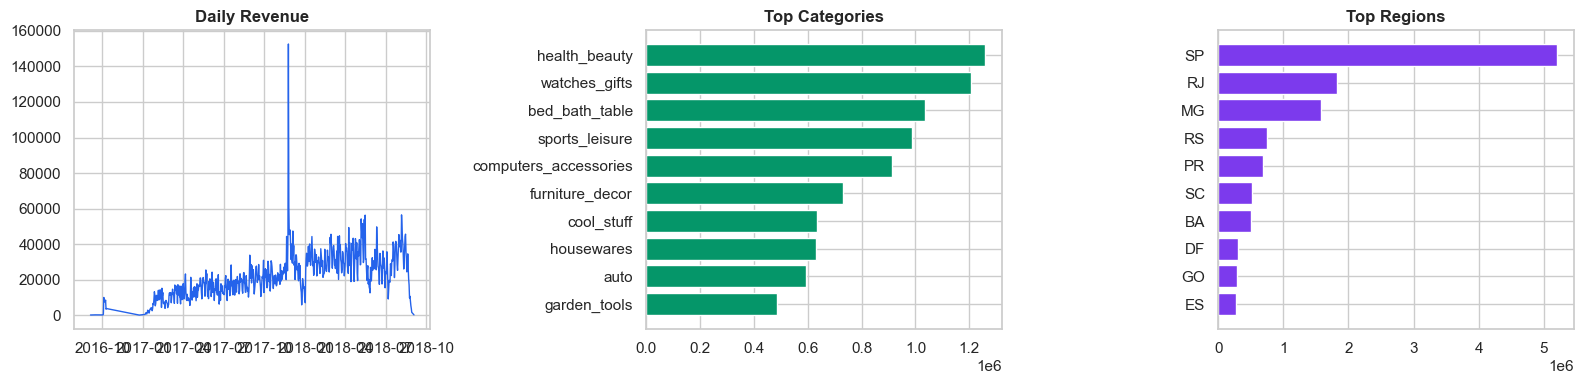

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(daily_sales["date"], daily_sales["revenue"], color="#2563eb", lw=1)
axes[0].set_title("Daily Revenue", fontweight="bold")

top10 = top_categories.head(10)
axes[1].barh(top10["product_category"], top10["revenue"], color="#059669")
axes[1].set_title("Top Categories", fontweight="bold")
axes[1].invert_yaxis()

top_reg = sales_by_region.head(10)
axes[2].barh(top_reg["region"], top_reg["revenue"], color="#7c3aed")
axes[2].set_title("Top Regions", fontweight="bold")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


## 21. Conclusion

Phase 5 prepared **Power BI–ready datasets** from `fact_sales` and Phase 3 forecasts:

| Page | Key exports |
|------|-------------|
| Executive Overview | `executive_overview.csv` |
| Sales Trends | `daily_sales.csv`, `monthly_sales.csv`, `forecast_vs_actual.csv` |
| Product Insights | `top_categories.csv`, `low_performing_products.csv` |
| Regional Analysis | `sales_by_region.csv`, `high_growth_regions.csv` |
| Modeling | `region_slicer.csv`, `category_slicer.csv`, `date_slicer.csv`, `hierarchies.csv`, `date_dimension.csv` |

**In Power BI:** import CSVs from `exports/`, relate `date_dimension` to fact dates, and build:

- **KPI cards** from `executive_overview`  
- **Trend lines** from daily/monthly sales and forecast comparison  
- **Drill-down** using hierarchy and slicer tables  
- **Bar charts** for categories and regions  

This completes the analytics stack: **warehouse (Phase 1) → insights (2) → forecast (3) → anomalies (4) → BI (5)**.
